In [1]:
import numpy as np

In [2]:
cvalues = [20.1, 20.8, 15, 17, 23, 27, 21, 20, 15]

In [3]:
C =np.array(cvalues)
print(C)

[20.1 20.8 15.  17.  23.  27.  21.  20.  15. ]


In [4]:
print(C* 9 / 5 + 32)

[68.18 69.44 59.   62.6  73.4  80.6  69.8  68.   59.  ]


In [5]:
type(C)

numpy.ndarray

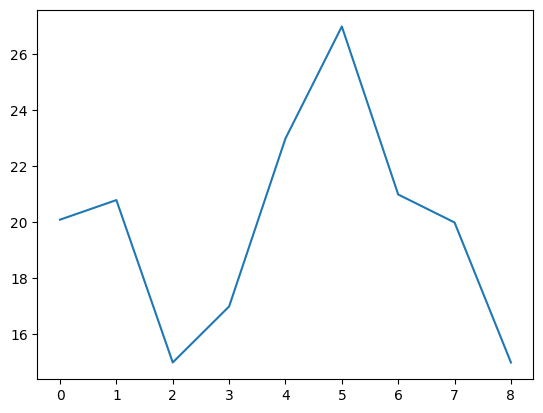

In [6]:
import matplotlib.pyplot as plt

plt.plot(C)
plt.show()


### Memory Consumption list object

The size of a Python list consists of the 

* general list information
* the size needed for the references to the elements
* the size of all the elements of the list. 

If we apply sys.getsizeof to a list, we get only the size without the size of the elements

In [7]:
from sys import getsizeof as size


lst = [24, 12, 57]

size_of_list_object = size(lst)
size_of_elements = len(lst) * size(lst[0])

total_list_size = size_of_elements + size_of_list_object

print("Size without the size of the elements: ", size_of_list_object)
print("Size of all elements: ", size_of_elements)
print("Total size of list including elements: ", total_list_size)

lst = [] # default empty list array is 56 because:  reference to internal array, capacity info 
print("Empty list size: ", size(lst))

lst.append(1)
print(size(lst))

lst.append(2)
print(size(lst))


Size without the size of the elements:  88
Size of all elements:  84
Total size of list including elements:  172
Empty list size:  56
88
88


In [8]:
a = np.array([24, 12, 57])
print(size(a))

136


In [9]:
e = np.array([])
print(size(e))

112


In [10]:
a = np.array([24, 12, 57], np.int8)
print(size(a) - 96)

a = np.array([24, 12, 57], np.int16)
print(size(a) - 96)

a = np.array([24, 12, 57], np.int32)
print(size(a) - 96)

a = np.array([24, 12, 57], np.int64)
print(size(a) - 96)

19
22
28
40


In [11]:
import time

size_of_vec = 10000000


def pure_python_version():
    t1 = time.time()

    X = range(size_of_vec)
    Y = range(size_of_vec)

    Z = [X[i] + Y[i] for i in range(len(X))]

    return time.time() - t1


def numpy_version():
    t1 = time.time()

    X = np.arange(size_of_vec)
    Y = np.arange(size_of_vec)

    Z = X + Y

    return time.time() - t1


t1 = pure_python_version()
t2 = numpy_version()

print(t1)
print(t2)
print(str(t1 // t2))

# In smaller arrays, the pure Python version can be faster than the NumPy version due to lower overhead. 
# However, as the size of the arrays increases, the performance advantage of NumPy becomes more pronounced, 
# and it can be significantly faster than pure Python for large arrays.

2.998149871826172
0.3856508731842041
7.0


In [12]:
import numpy as np
from timeit import Timer

size_of_vec = 1_000_000

X_list = range(size_of_vec)
Y_list = range(size_of_vec)

X = np.arange(size_of_vec)
Y = np.arange(size_of_vec)

def pure_python_version():
    Z = [X_list[i] + Y_list[i] for i in range(len(X_list))]


def numpy_version():
    Z = X + Y


timer_obj1 = Timer("pure_python_version()", "from __main__ import pure_python_version")
timer_obj2 = Timer("numpy_version()", "from __main__ import numpy_version")


for i in range(3):
    t1 = timer_obj1.timeit(10)
    t2 = timer_obj2.timeit(10)

    print("Pure Python Version: ", t1)
    print("time for Numpy Version", t2)
    print(t1 / t2)

Pure Python Version:  2.7079773629993724
time for Numpy Version 0.024334220001037465
111.28268598228834
Pure Python Version:  1.5362542219991155
time for Numpy Version 0.026337748000514694
58.32898932623602
Pure Python Version:  1.4648669110029005
time for Numpy Version 0.024570494002546184
59.618944204015584
